In [1]:
%load_ext autoreload
%autoreload 2
# Import all functions and constants from the steering_analysis module
# The steering_analysis.py file is in the same directory (src/steering/)
import sys
from pathlib import Path

# Ensure we can import from the steering directory
# In Jupyter, the current working directory is usually the project root
current_dir = Path.cwd()
steering_dir = current_dir / 'src' / 'steering'
if str(steering_dir) not in sys.path:
    sys.path.insert(0, str(steering_dir))

# Import from steering_analysis module
from steering_analysis import (
    analyze_steering_results,
    is_mixture_dataset,
    create_mixture_label,
    discover_datasets,
    load_steering_results,
    get_spi_difference_same_vs_mixture,
    pick_row_single,
    pick_row_multi,
    get_spi_dataframe,
    plot_spi_heatmap_matrix,
    ROOT,
    DEFAULT_DATASETS,
    DEFAULT_MODELS,
    DEFAULT_METHODS,
)



Using steering type: logit
Token position: exact
Calibration target: both

[DEBUG] Available steering_keys for MMLU-PROF / Llama-3.1-8B-Instruct:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing Vanilla Contrastive (exact) for MMLU-PROF / Llama-3.1-8B-Instruct

Plot saved to: outputs/separate_models/llama_instruct_logit_exact.png


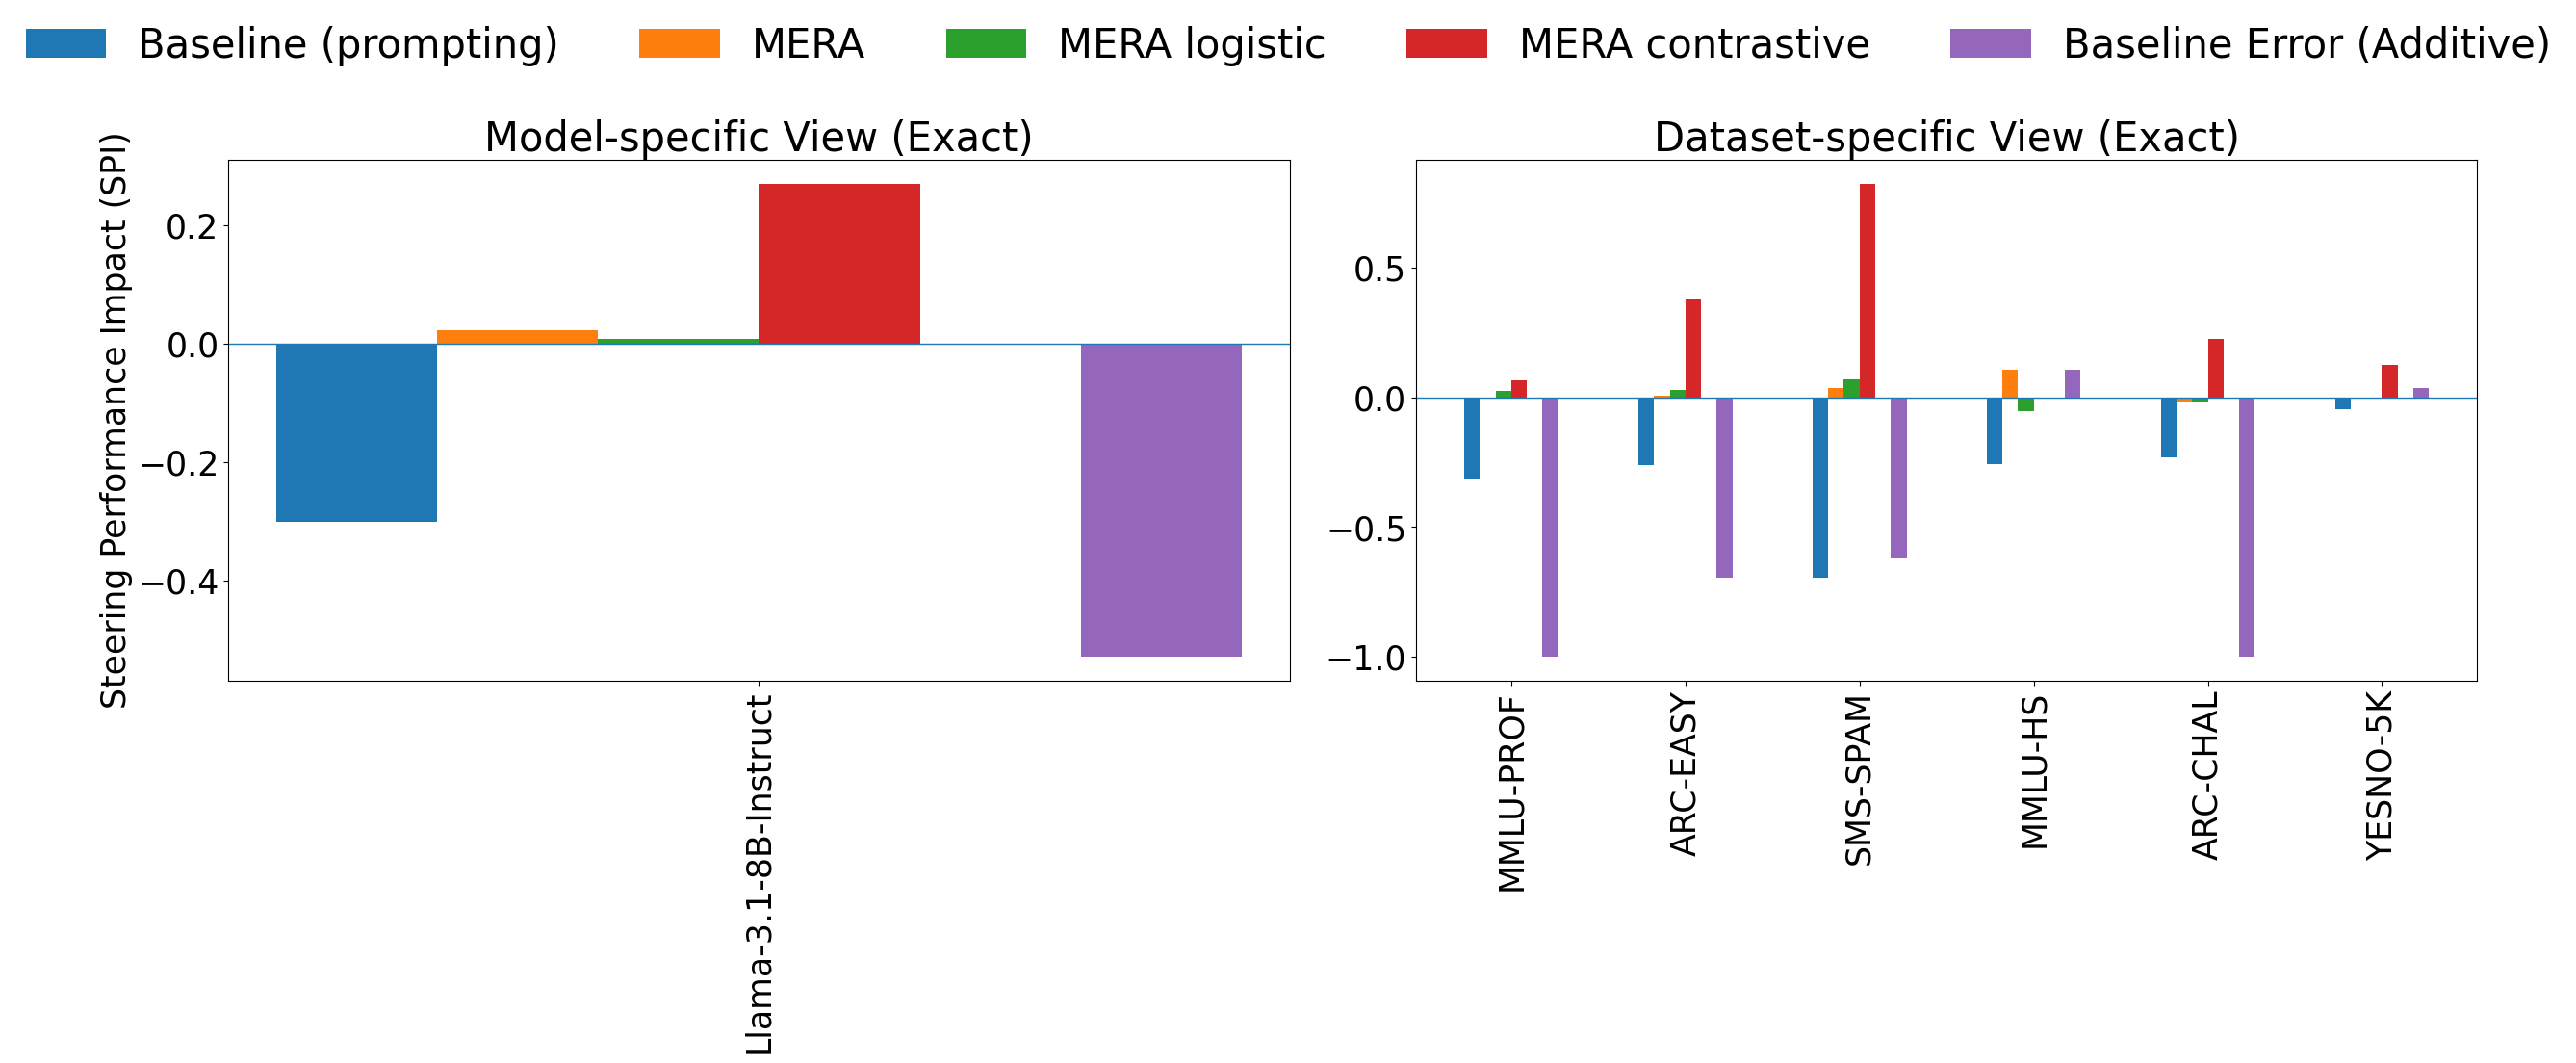

Using steering type: logit
Token position: exact
Calibration target: both

[DEBUG] Available steering_keys for MMLU-PROF / Llama-3.1-8B:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing Vanilla Contrastive (exact) for MMLU-PROF / Llama-3.1-8B

Results shape: (

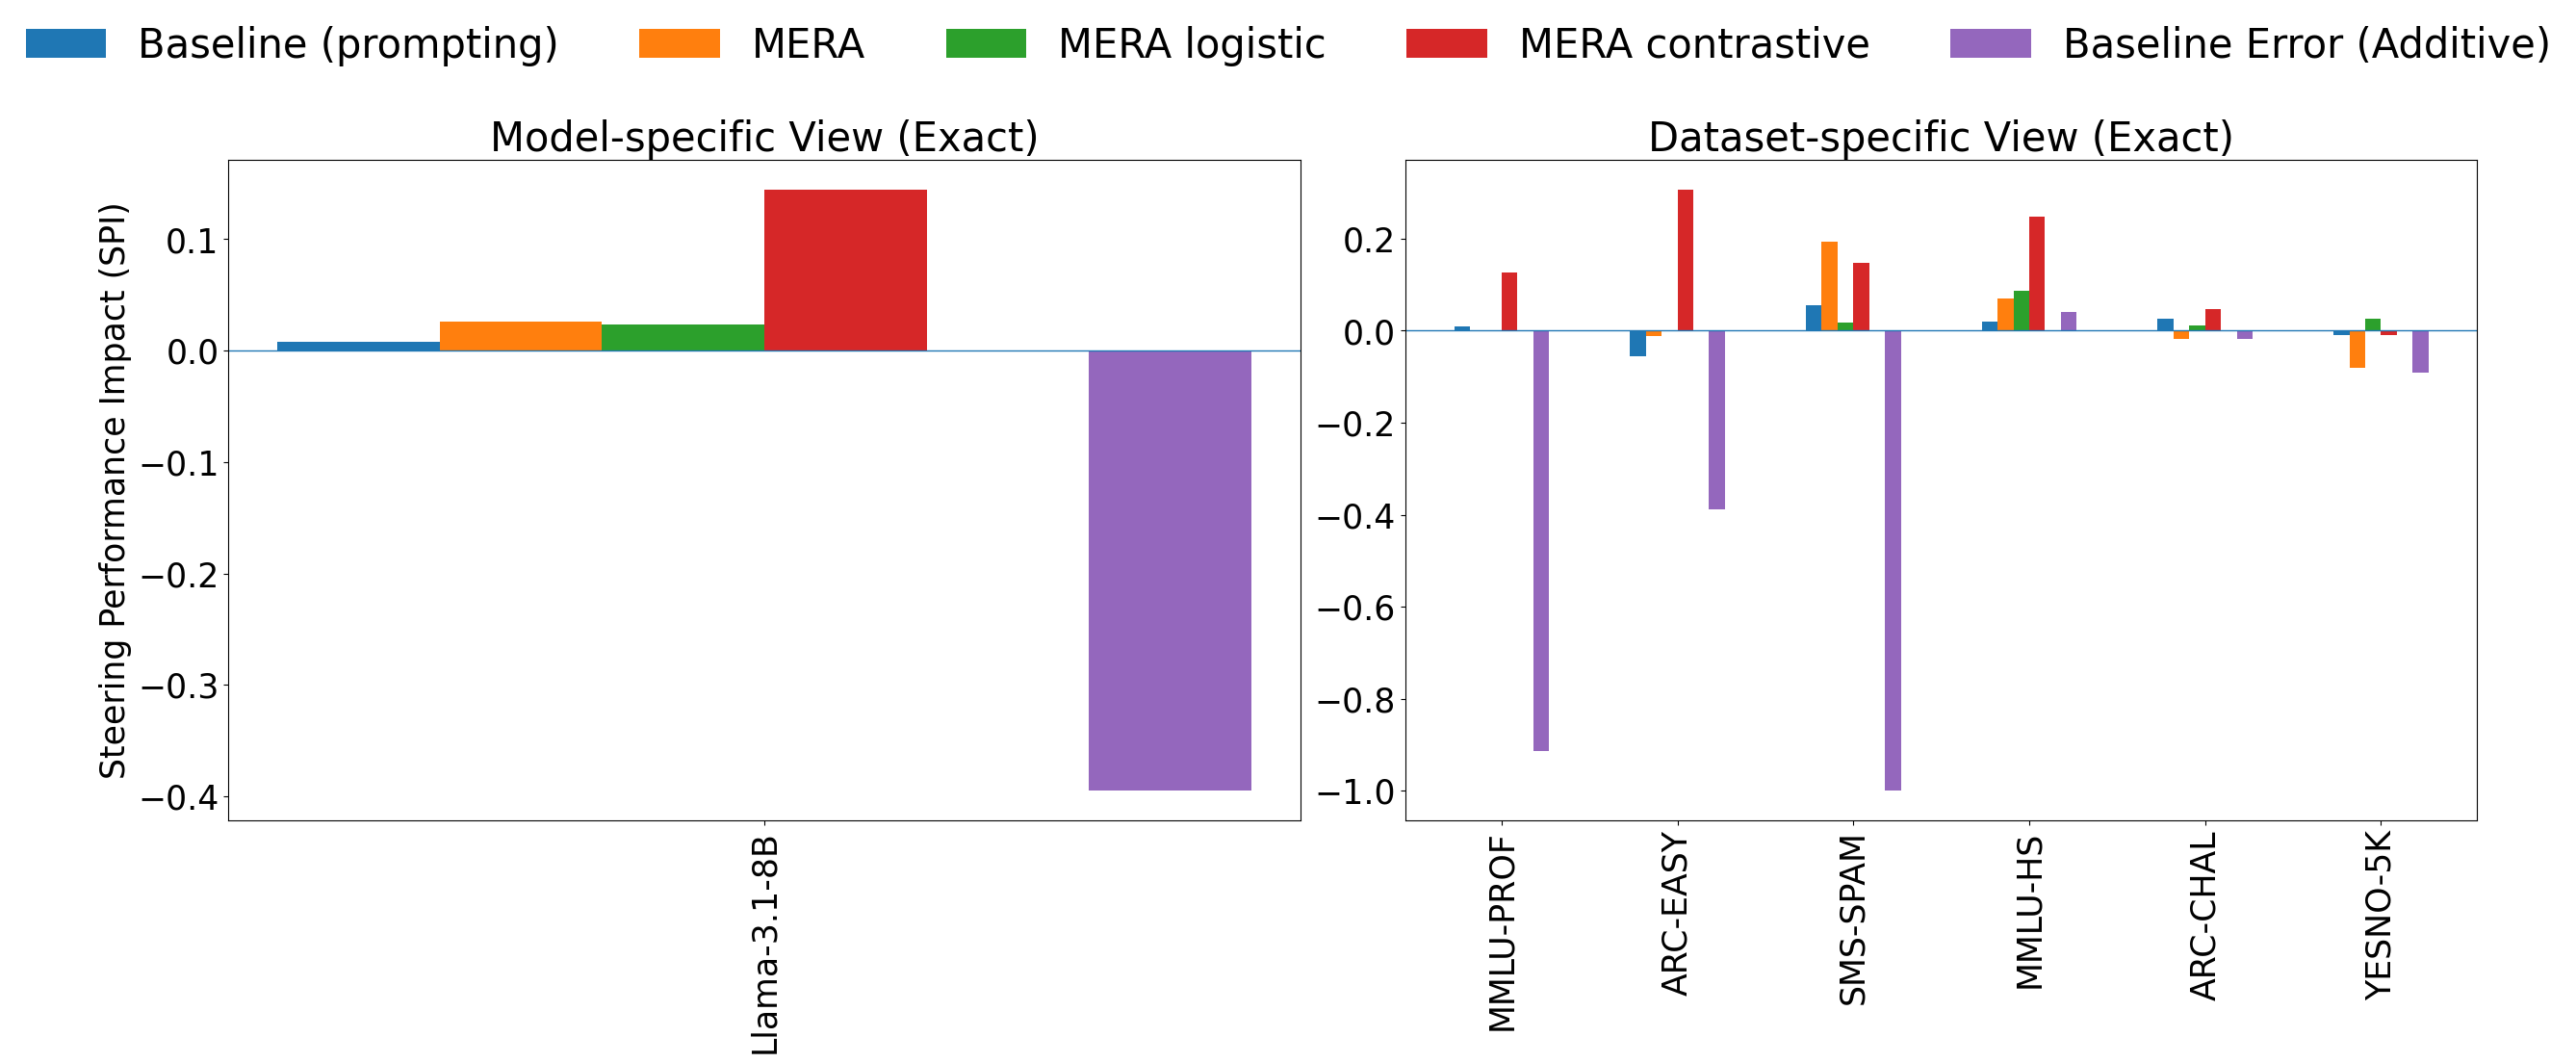

Using steering type: logit
Token position: exact
Calibration target: both

[DEBUG] Available steering_keys for MMLU-PROF / Apertus-8B-Instruct:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing MERA (exact) for MMLU-PROF / Apertus-8B-Instruct
[WARN] Missing Vanilla Contrastive (exact) for MMLU-PROF / Apertus-8B-Instruct

Results shape: (27, 8)
      Dataset                Model                

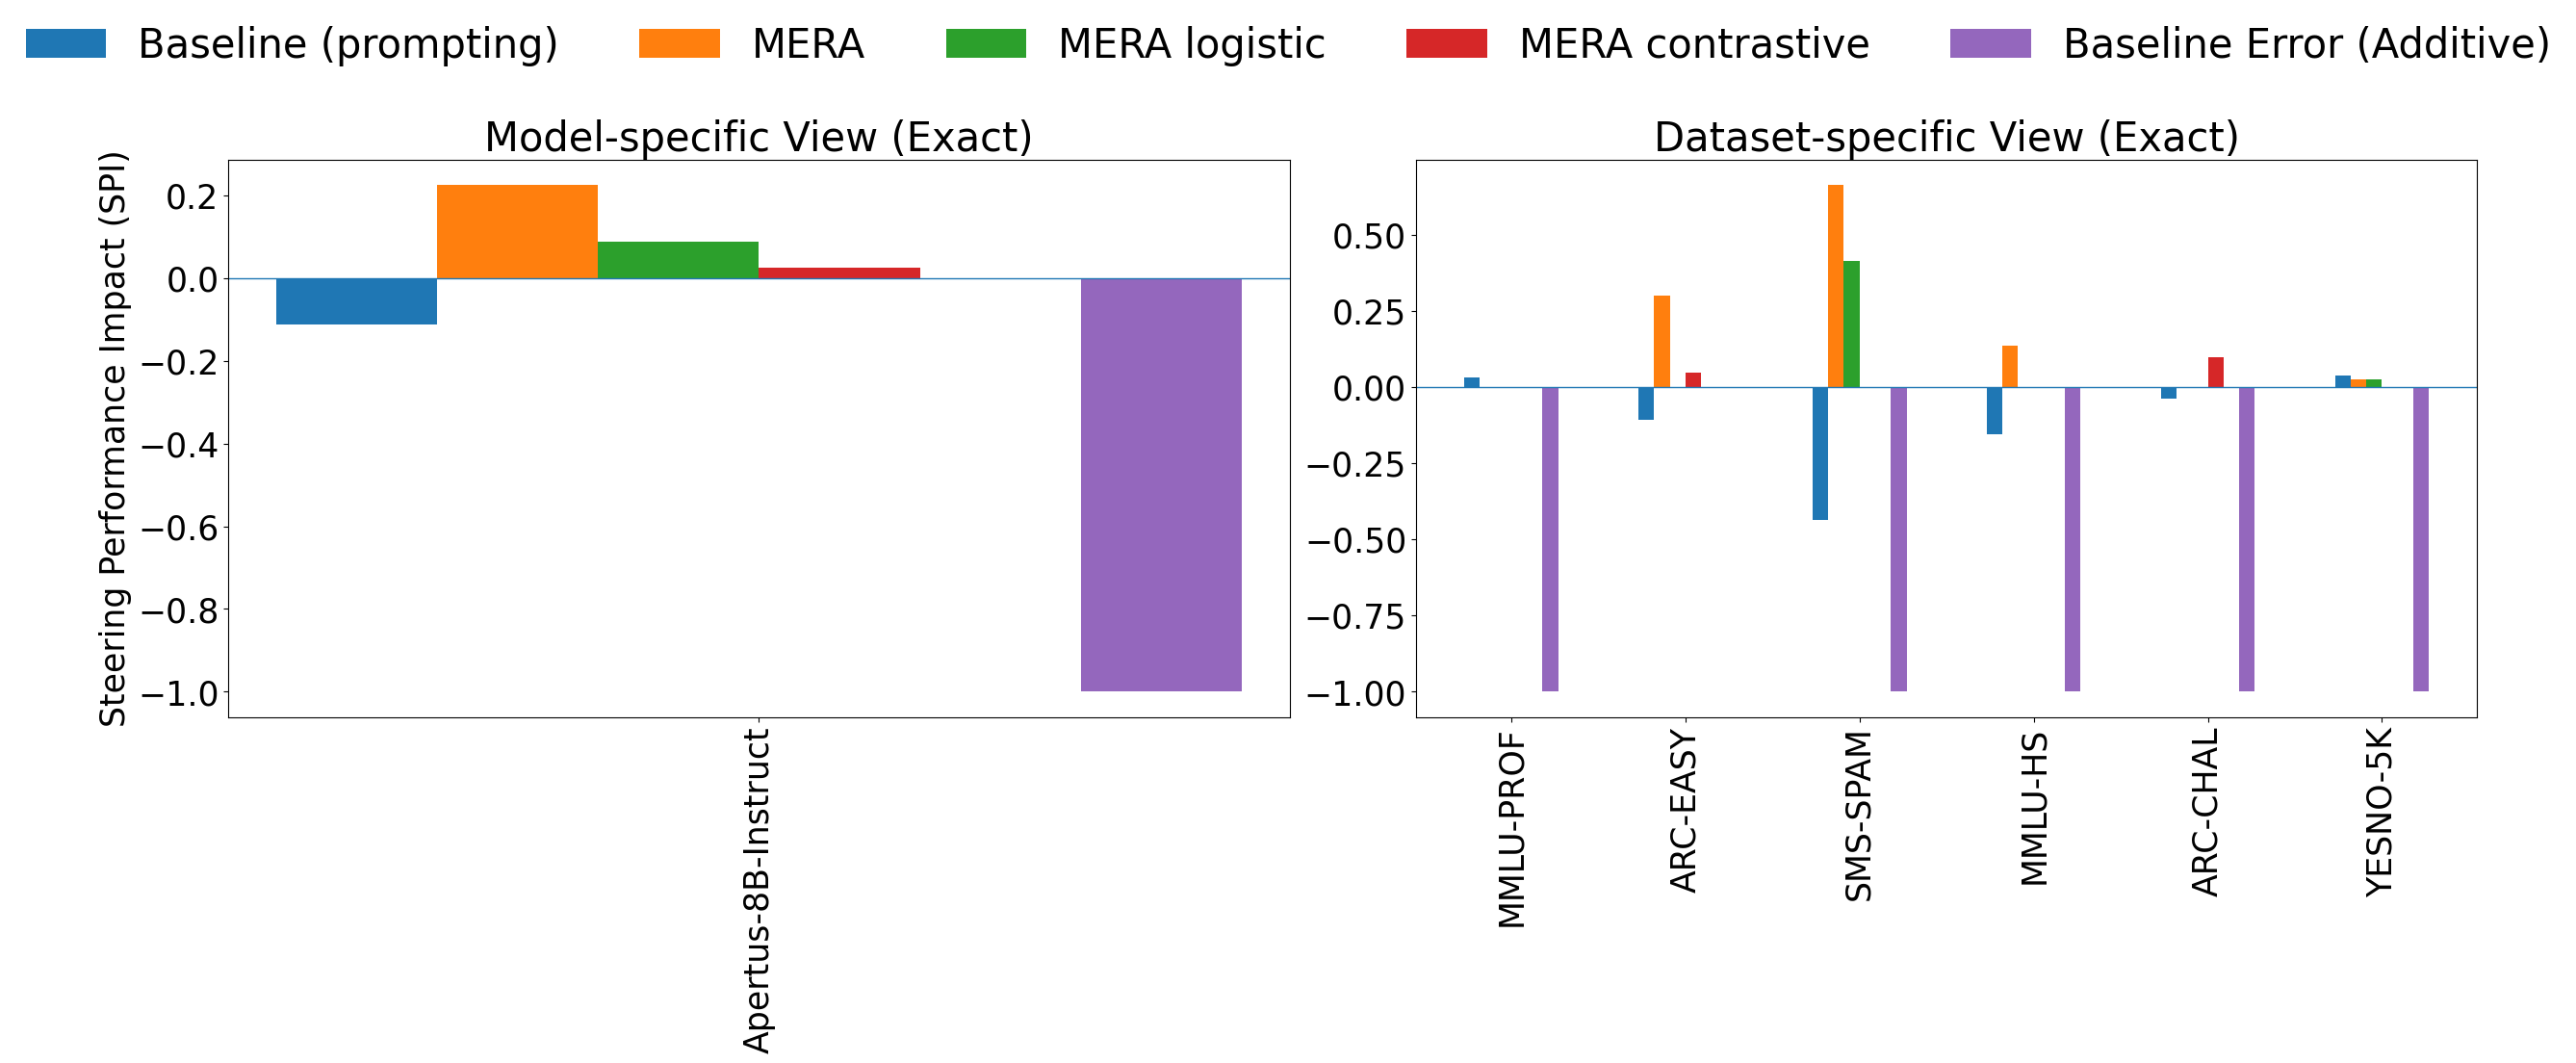

Using steering type: logit
Token position: exact
Calibration target: both

[DEBUG] Available steering_keys for MMLU-PROF / Apertus-8B:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing Vanilla Contrastive (exact) for MMLU-PROF / Apertus-8B

Results shape: (30, 

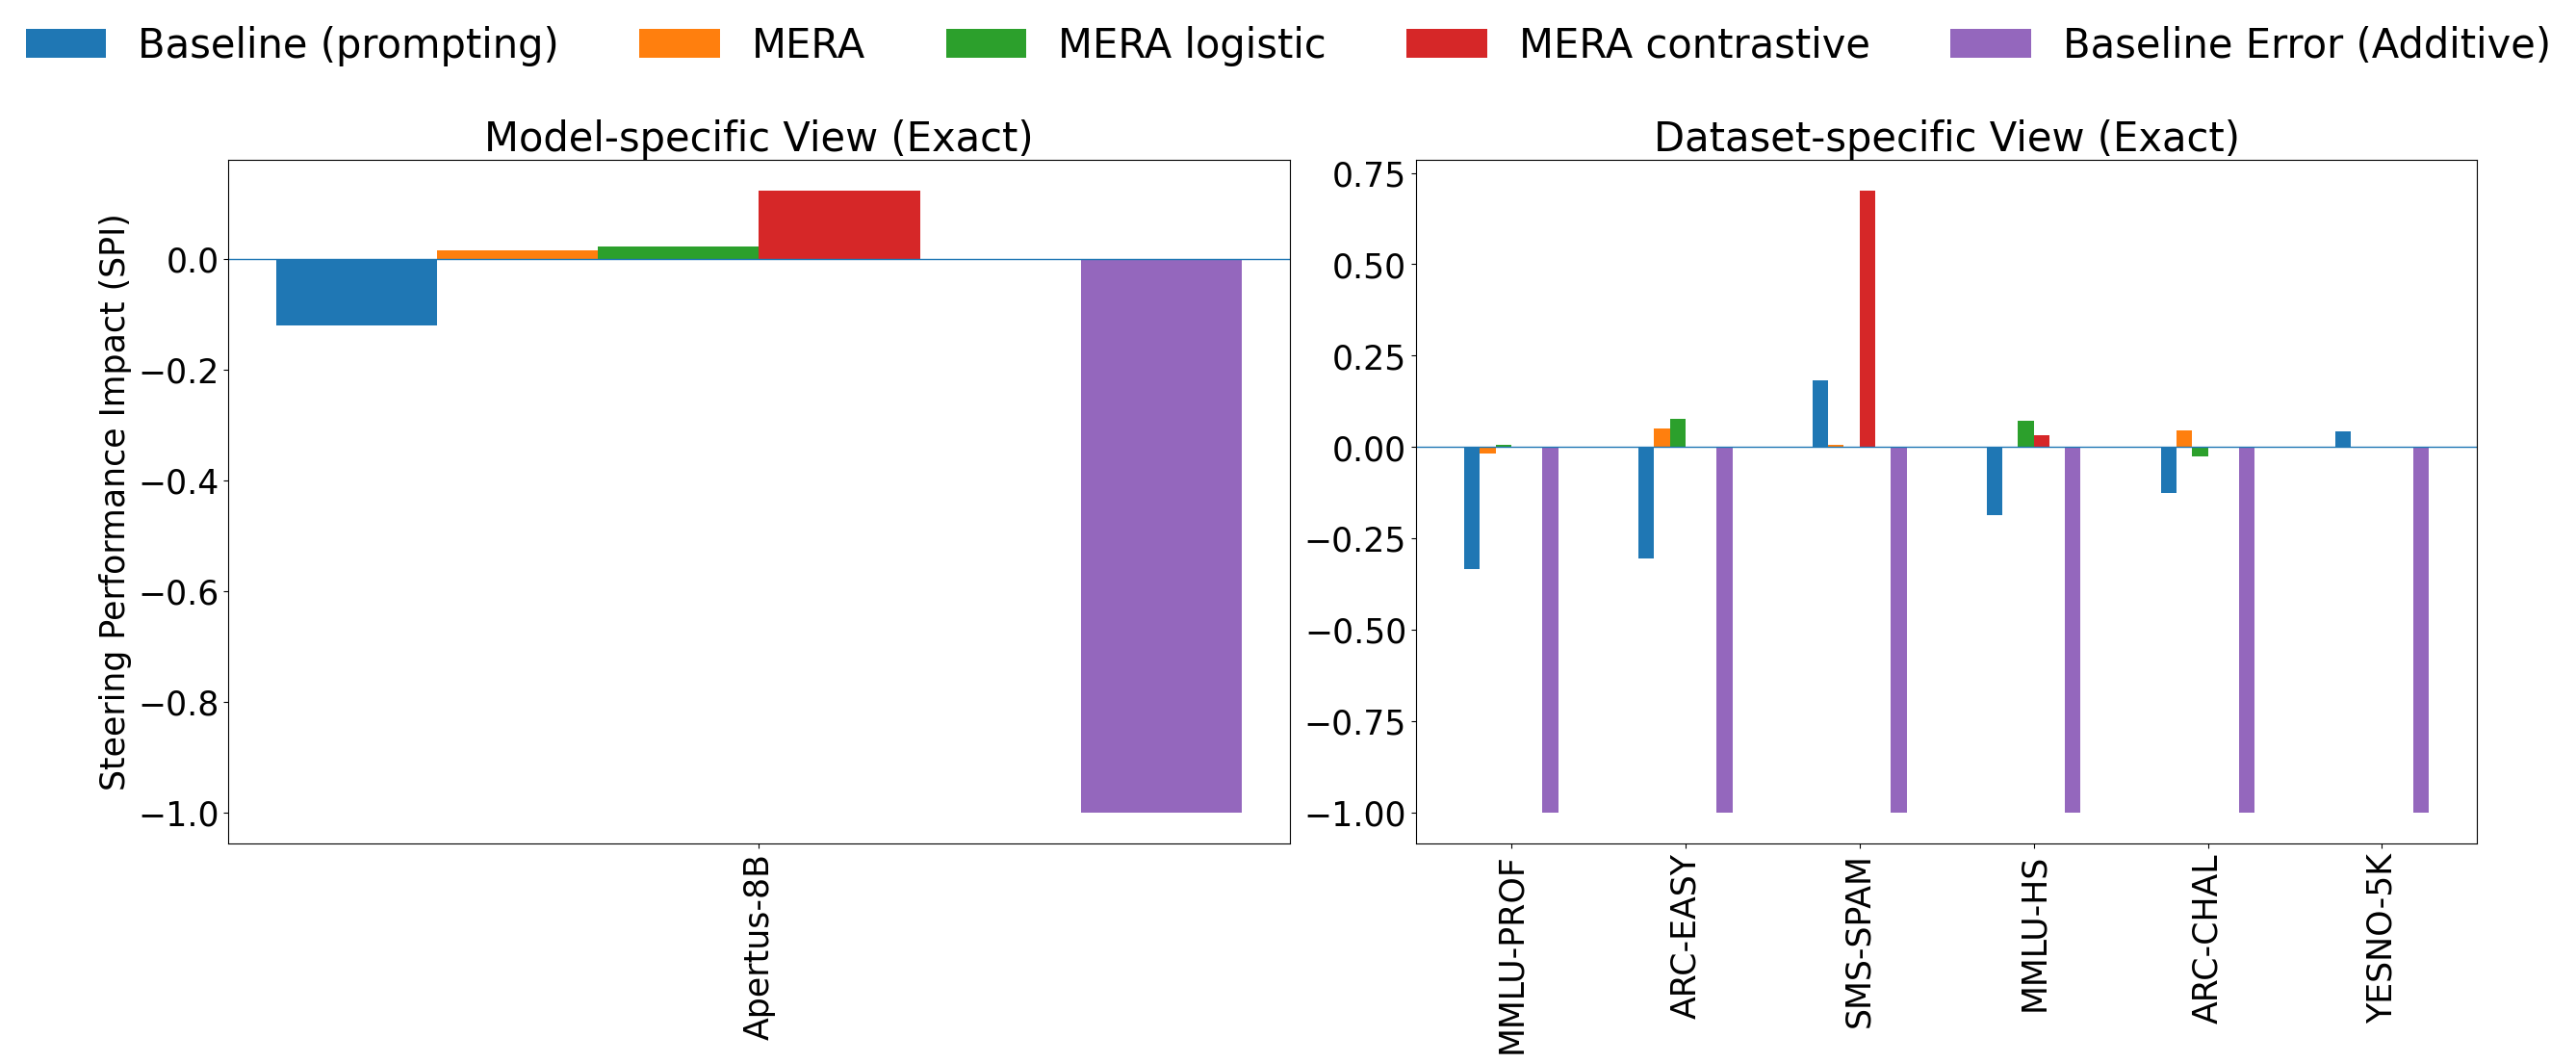

In [26]:
TOKEN_POS = "exact"  # Options: "exact", "last"
PROBE_TYPE = "logit"  # Options: "logit", "linear"

mixture_datasets = {
    "MMLU-PROF": "mmlu_professional_steered_on_mmlu_professional",
    "ARC-EASY": "ARC-Easy_steered_on_ARC-Easy",
    "SMS-SPAM": "sms_spam_steered_on_sms_spam",
    "MMLU-HS": "mmlu_high_school_steered_on_mmlu_high_school",
    "ARC-CHAL": "ARC-Challenge_steered_on_ARC-Challenge",
    "YESNO-5K": "sujet_finance_yesno_5k_steered_on_sujet_finance_yesno_5k",
}
# SEPARATE MODELS
# LLAMA INSTRUCT
custom_models = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
}
res_comparison = analyze_steering_results(
    models=custom_models,
    datasets=mixture_datasets,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"outputs/separate_models/llama_instruct_{PROBE_TYPE}_{TOKEN_POS}.png"
)



# LLAMA BASE
custom_models = {
    "Llama-3.1-8B": "Llama-3.1-8B",
}
res_comparison = analyze_steering_results(
    models=custom_models,
    datasets=mixture_datasets,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"outputs/separate_models/llama_base_{PROBE_TYPE}_{TOKEN_POS}.png"
)  

# APERTUS INSTRUCT
custom_models = {
    "Apertus-8B-Instruct": "Apertus-8B-Instruct-2509",
}

res_comparison = analyze_steering_results(
    models=custom_models,
    datasets=mixture_datasets,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"outputs/separate_models/apertus_instruct_{PROBE_TYPE}_{TOKEN_POS}.png"
)

# APERTUS BASE
custom_models = {
    "Apertus-8B": "Apertus-8B-2509",
}


res_comparison = analyze_steering_results(
    models=custom_models,
    datasets=mixture_datasets,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"outputs/separate_models/apertus_base_{PROBE_TYPE}_{TOKEN_POS}.png"
)






Using steering type: linear
Token position: last
Calibration target: both

[DEBUG] Available steering_keys for MMLU-PROF / Llama-3.1-8B-Instruct:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing Vanilla Contrastive (last) for MMLU-PROF / Llama-3.1-8B-Instruct


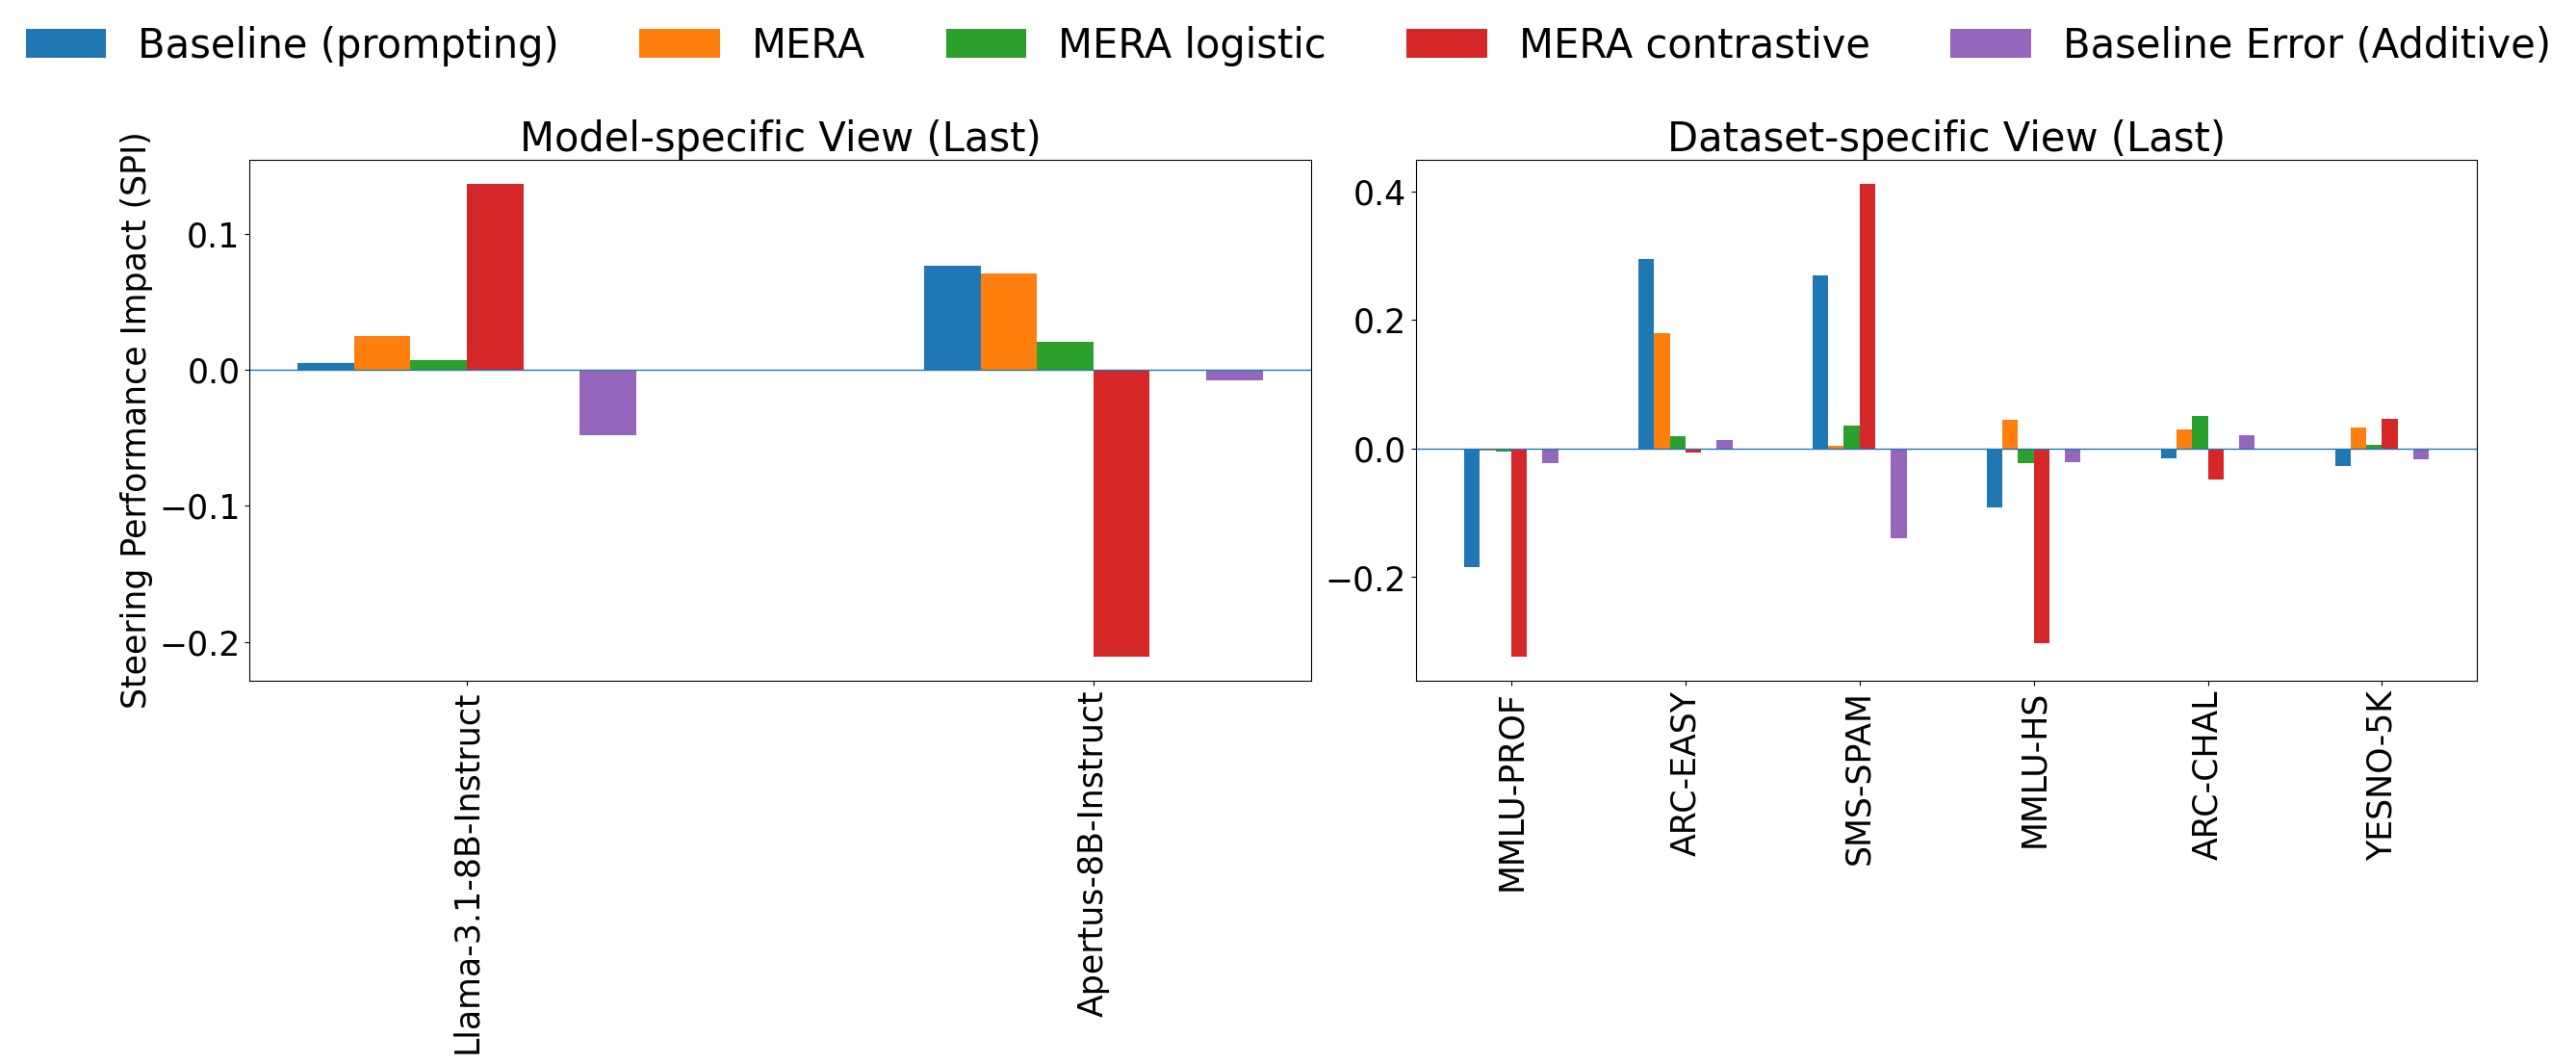

Using steering type: linear
Token position: last
Calibration target: both

[DEBUG] Available steering_keys for MMLU-PROF / Llama-3.1-8B:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing Vanilla Contrastive (last) for MMLU-PROF / Llama-3.1-8B

Results shape: (6

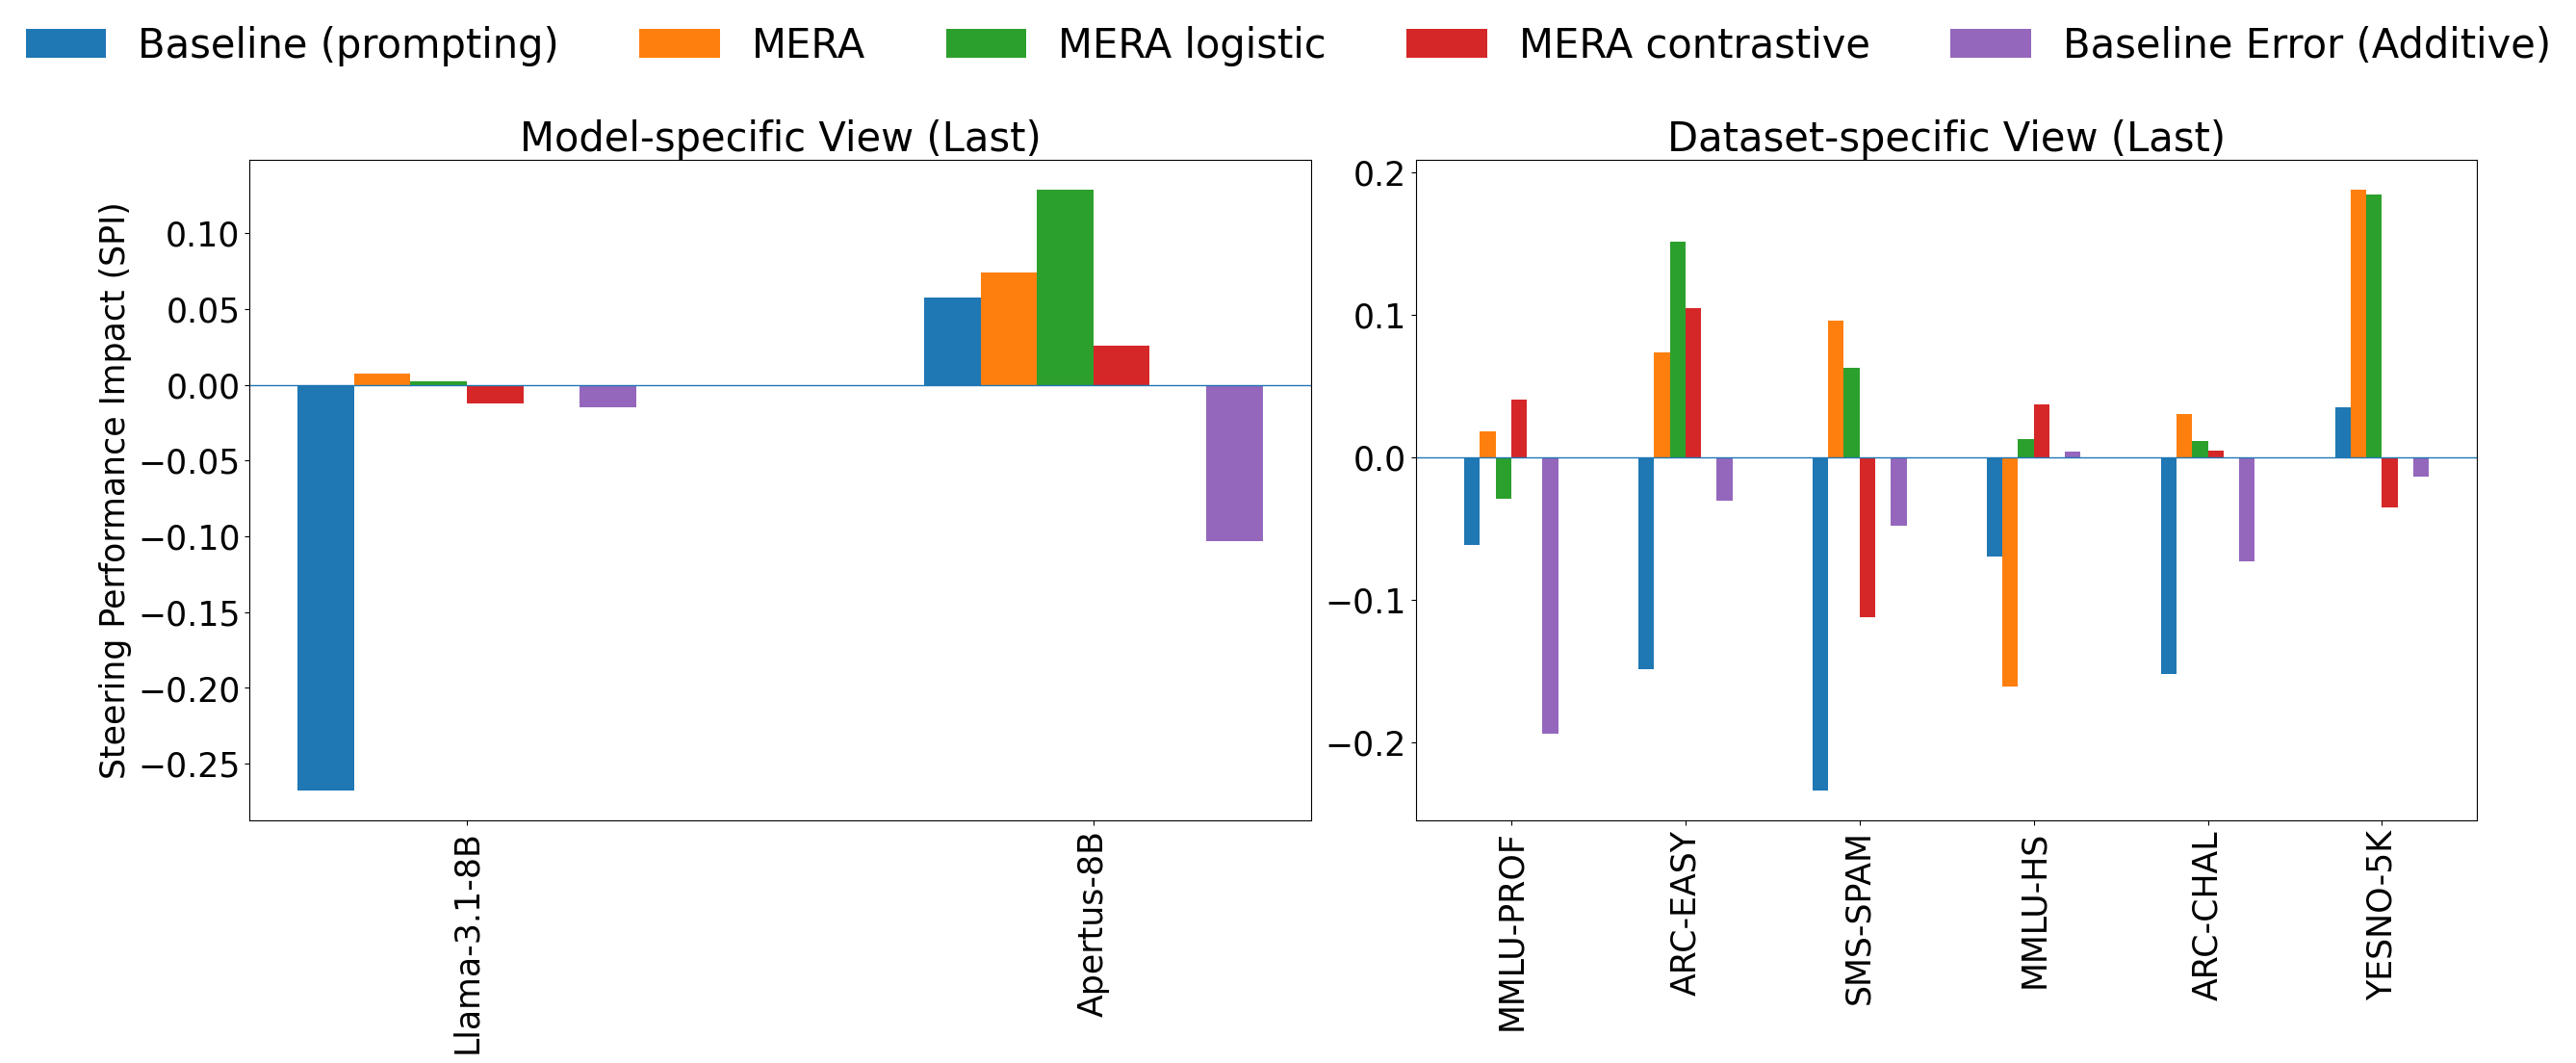

In [28]:
PROBE_TYPE = "linear"  # Options: "logit", "linear"
TOKEN_POS = "last"  # Options: "exact", "last"

# INSTRUCT MODELS
custom_models = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
    "Apertus-8B-Instruct": "Apertus-8B-Instruct-2509",
}

res_comparison = analyze_steering_results(
    models=custom_models,
    datasets=mixture_datasets,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"outputs/instruct_models_{PROBE_TYPE}_{TOKEN_POS}.png"
)

# BASE MODELS
custom_models = {
    "Llama-3.1-8B": "Llama-3.1-8B",
    "Apertus-8B": "Apertus-8B-2509",
}
res_comparison = analyze_steering_results(
    models=custom_models,
    datasets=mixture_datasets,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"outputs/base_models_{PROBE_TYPE}_{TOKEN_POS}.png"
)



Using steering type: logit
Token position: exact
Calibration target: both

[DEBUG] Available steering_keys for MMLU-PROF / Llama:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing Vanilla Contrastive (exact) for MMLU-PROF / Llama

Results shape: (120, 8)
      

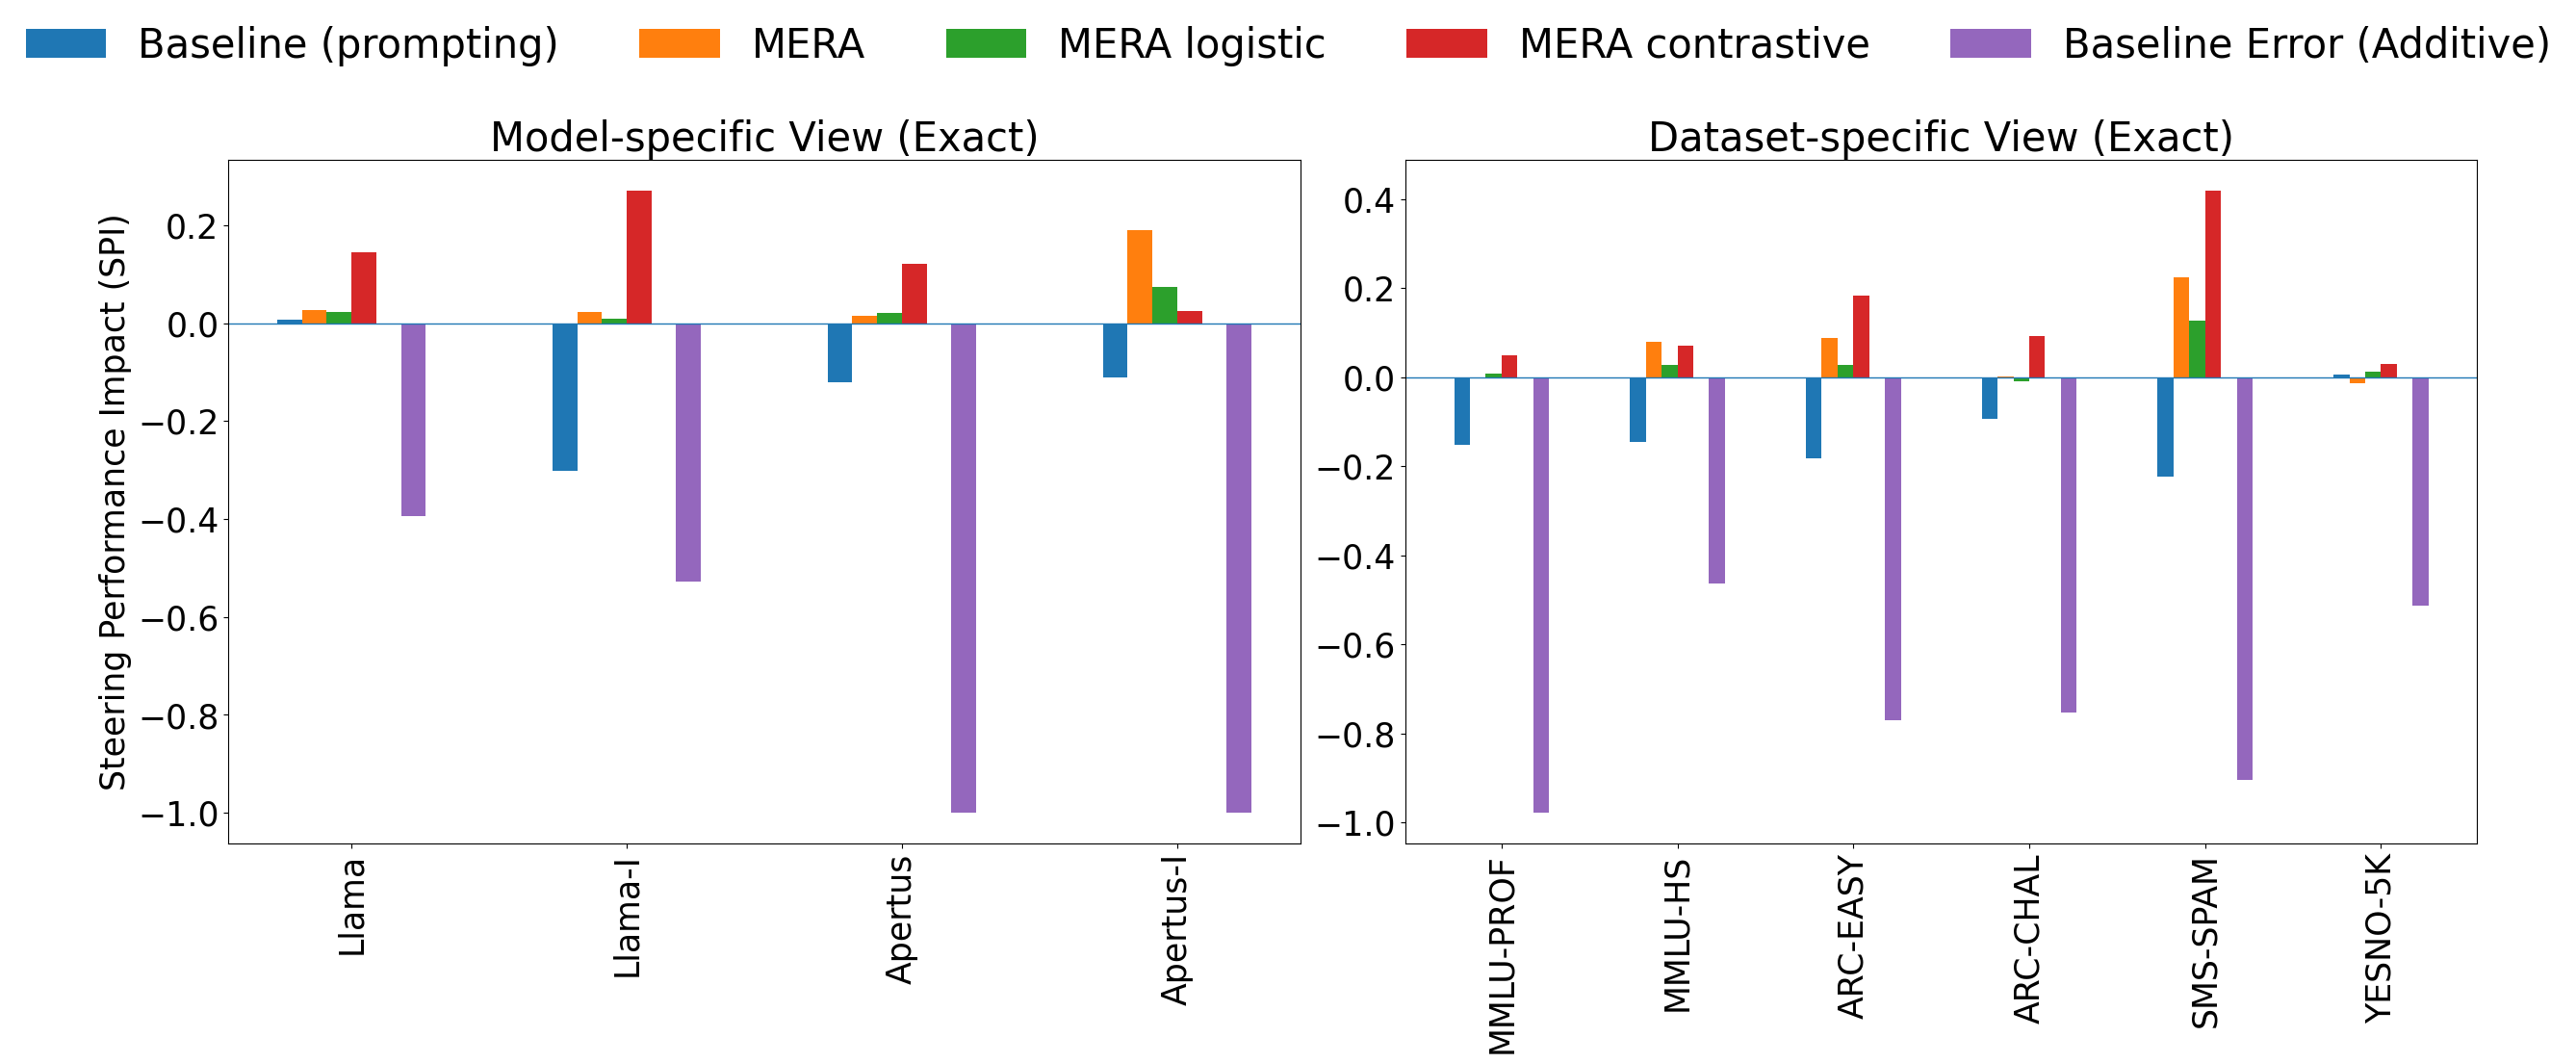

In [ ]:
TOKEN_POS = "exact"  # Options: "exact", "last"
PROBE_TYPE = "linear"  # Options: "logit", "linear"

mixture_datasets = {
    "MMLU-PROF": "mmlu_professional_steered_on_mmlu_professional",
    "MMLU-HS": "mmlu_high_school_steered_on_mmlu_high_school",
    "ARC-EASY": "ARC-Easy_steered_on_ARC-Easy",
    "ARC-CHAL": "ARC-Challenge_steered_on_ARC-Challenge",
    "SMS-SPAM": "sms_spam_steered_on_sms_spam",
    "YESNO-5K": "sujet_finance_yesno_5k_steered_on_sujet_finance_yesno_5k",
}
# all models
custom_models = {
    "Llama": "Llama-3.1-8B",
    "Llama-I": "Llama-3.1-8B-Instruct",
    "Apertus": "Apertus-8B-2509",
    "Apertus-I": "Apertus-8B-Instruct-2509",
}

res_comparison = analyze_steering_results(
    models=custom_models,
    datasets=mixture_datasets,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"new/all_models_{PROBE_TYPE}_{TOKEN_POS}.png"
)


Using steering type: linear
Token position: exact
Calibration target: both
[WARN] No steering PKLs found for type 'linear' in /capstor/store/cscs/swissai/infra01/apertus_probes/mera-runs/steering_outputs/mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_mmlu_high_school/Llama-3.1-8B/steering
[WARN] No steering PKLs found for type 'linear' in /capstor/store/cscs/swissai/infra01/apertus_probes/mera-runs/steering_outputs/mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_mmlu_high_school/Llama-3.1-8B-Instruct/steering
[WARN] No steering PKLs found for type 'linear' in /capstor/store/cscs/swissai/infra01/apertus_probes/mera-runs/steering_outputs/mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_mmlu_high_school/Apertus-8B-2509/steering
[WARN] No steering PKLs found for type 'linear' in /capstor/store/cscs/swissai/infra01/apertus_probes/mera


Results shape: (120, 8)
          Dataset      Model                     Method  SPI Last  Err25 Last  \
0     Mix→MMLU-HS      Llama       Baseline (prompting) -0.255556    0.488638   
1     Mix→MMLU-HS      Llama                       MERA  0.000000    0.471898   
2     Mix→MMLU-HS      Llama              MERA logistic -0.011111    0.498414   
3     Mix→MMLU-HS      Llama           MERA contrastive  0.118750    0.447903   
4     Mix→MMLU-HS      Llama  Baseline Error (Additive) -0.277778    0.648305   
5     Mix→MMLU-HS    Llama-I       Baseline (prompting) -0.125000    0.391441   
6     Mix→MMLU-HS    Llama-I                       MERA -0.009615    0.463579   
7     Mix→MMLU-HS    Llama-I              MERA logistic  0.000000    0.463154   
8     Mix→MMLU-HS    Llama-I           MERA contrastive  0.205479    0.177199   
9     Mix→MMLU-HS    Llama-I  Baseline Error (Additive) -0.413462    0.634115   
10    Mix→MMLU-HS    Apertus       Baseline (prompting)  0.116667    0.415318   
11 

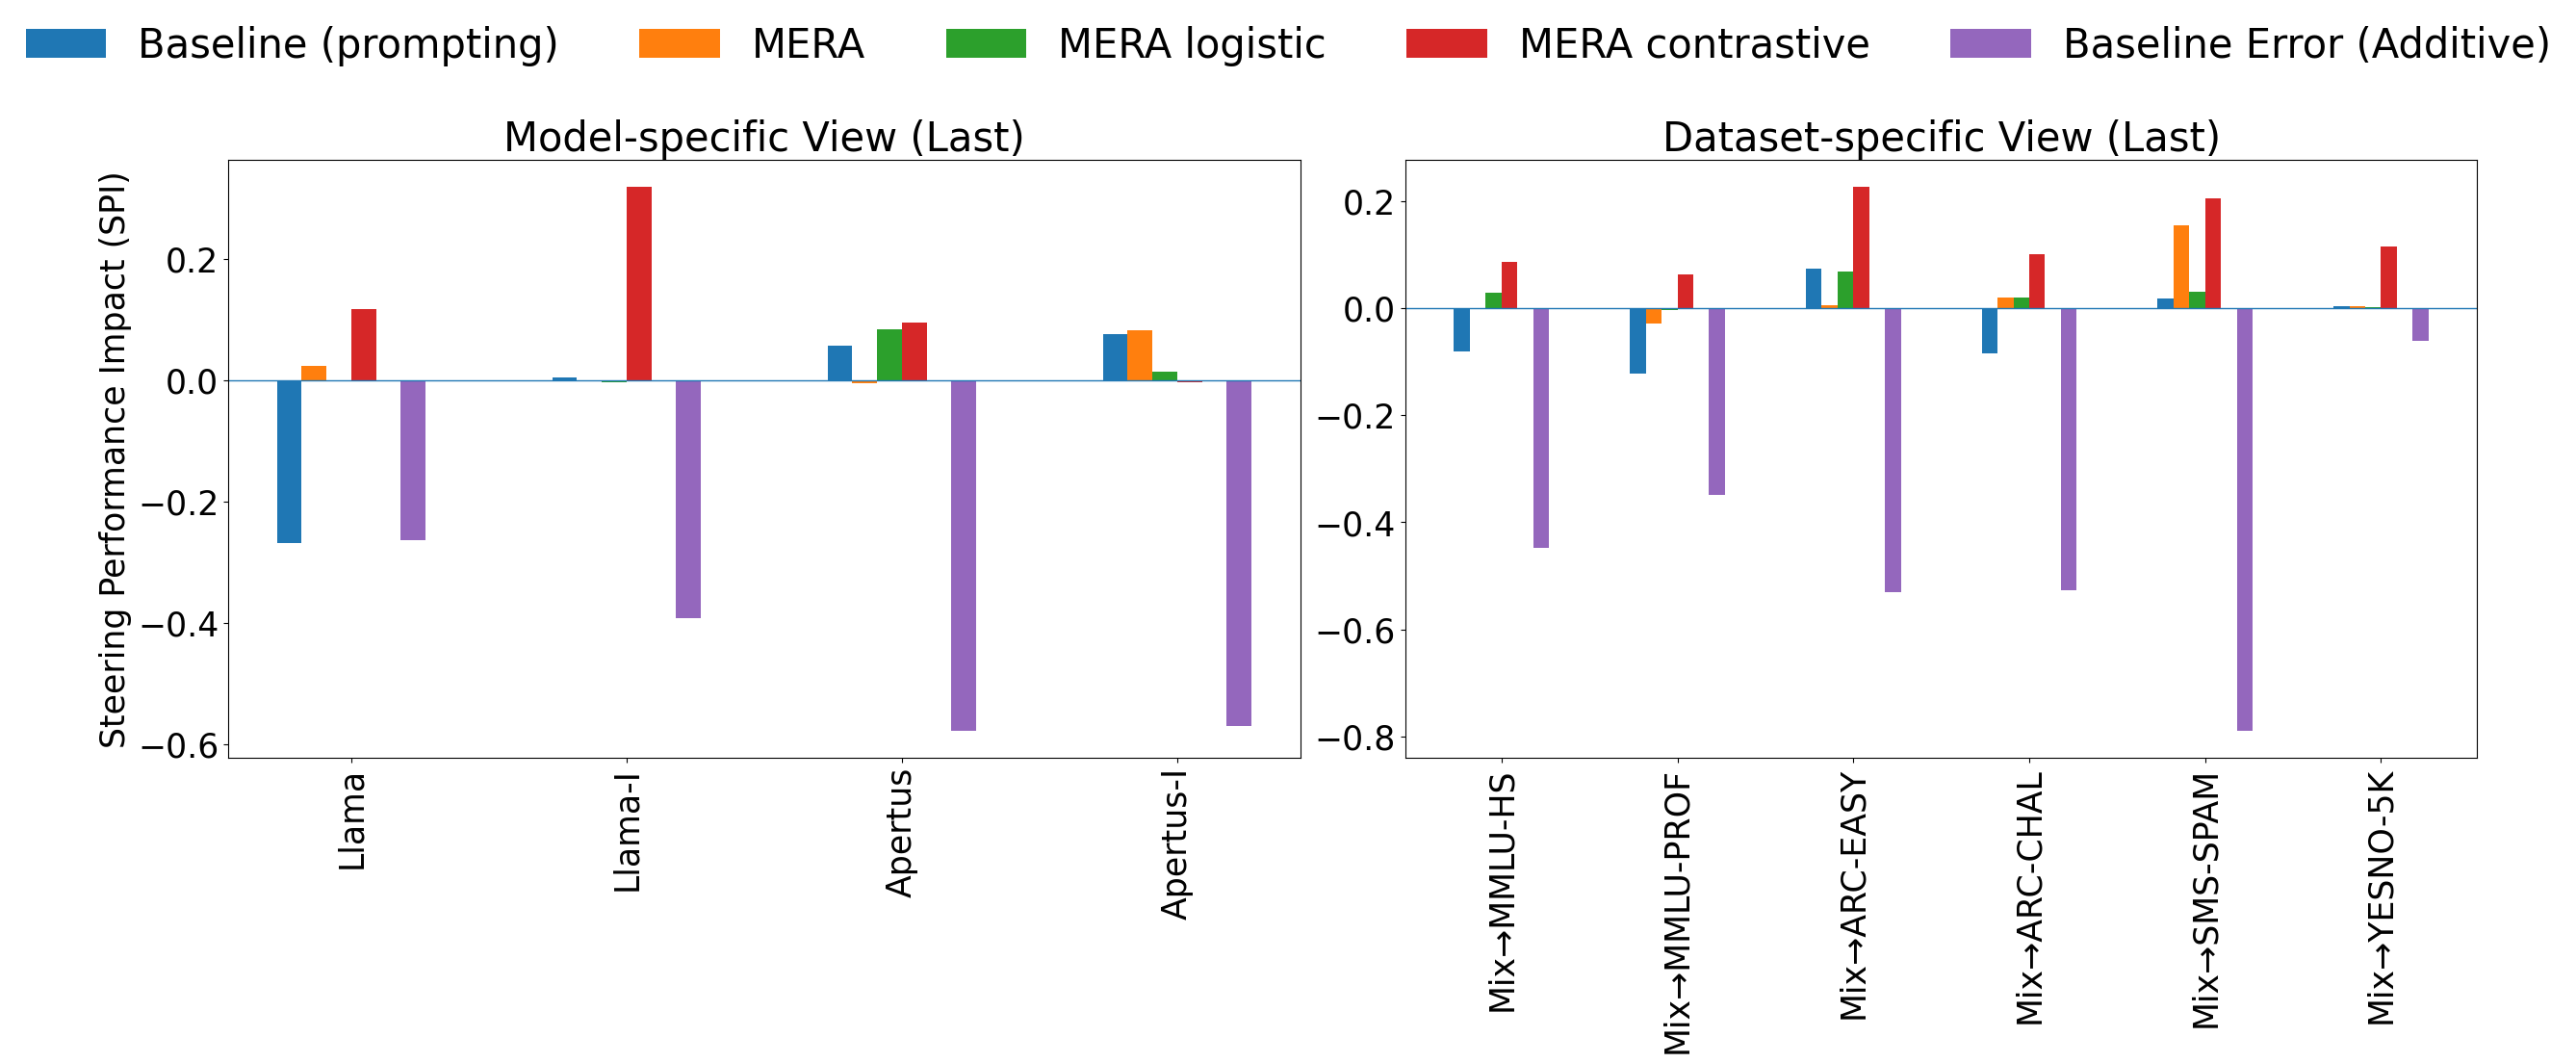


Data shape: (120, 8)

Summary by dataset:
               SPI Last
Dataset                
Mix→ARC-CHAL  -0.094635
Mix→ARC-EASY  -0.031770
Mix→MMLU-HS   -0.083186
Mix→MMLU-PROF -0.088352
Mix→SMS-SPAM  -0.076396
Mix→YESNO-5K   0.012516


In [60]:
TOKEN_POS = "exact"  # Options: "exact", "last"
PROBE_TYPE = "linear"  # Options: "logit", "linear"

# MIXTURE DATASETS
mixture_datasets = {
    "Mix→MMLU-HS": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_mmlu_high_school",
    "Mix→MMLU-PROF": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_mmlu_professional",
    "Mix→ARC-EASY": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_ARC-Easy",
    "Mix→ARC-CHAL": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_ARC-Challenge",
    "Mix→SMS-SPAM": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_sms_spam",
    "Mix→YESNO-5K": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_sujet_finance_yesno_5k",
}

res_comparison = analyze_steering_results(
    datasets=mixture_datasets,
    models=custom_models,
    token_position=TOKEN_POS,
    steering_type=PROBE_TYPE,
    plot=True,
    save_path=f"new/mixture_datasets_{PROBE_TYPE}_{TOKEN_POS}.png"
)

# Example 6: Get data without plotting, then plot manually
res_data_only = analyze_steering_results(
    datasets=mixture_datasets,
    models=custom_models,
    token_position="last",
    steering_type="logit",
    plot=True,  # Don't auto-plot
    

)

# Now you can do custom analysis or plotting on res_data_only
print(f"\nData shape: {res_data_only.shape}")
print("\nSummary by dataset:")
print(res_data_only.groupby("Dataset")[["SPI Last"]].mean())



In [58]:
same_datasets={
        "MMLU-HS": "mmlu_high_school_steered_on_mmlu_high_school",
        "MMLU-PROF": "mmlu_professional_steered_on_mmlu_professional",
        "ARC-EASY": "ARC-Easy_steered_on_ARC-Easy",
        "ARC-CHAL": "ARC-Challenge_steered_on_ARC-Challenge",
        "SMS-SPAM": "sms_spam_steered_on_sms_spam",
        "YESNO-5K": "sujet_finance_yesno_5k_steered_on_sujet_finance_yesno_5k"
    },
custom_models = {
    "Llama": "Llama-3.1-8B",
    "Llama-I": "Llama-3.1-8B-Instruct",
    "Apertus": "Apertus-8B-2509",
    "Apertus-I": "Apertus-8B-Instruct-2509",
}
df = get_spi_dataframe(
    models=custom_models,
    datasets=same_datasets,
    token_positions=["exact", "last"],  # or just ["last"] or ["exact"]
    probe_types=["linear", "logit"],     # or just one of them
    debug=True  # Set to False to reduce output
)


Processing probe type: linear

Processing token position: exact
Using steering type: linear
Token position: exact
Calibration target: both

[DEBUG] Available steering_keys for MMLU-HS / Llama:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] Missing Vanilla Contrasti

In [57]:
row_ex = {"Model": "Llama", "Dataset": "MMLU-PROF", "Token Position": "exact", "Method": "MERA", "SPI": 0.12, "SPI Exact": 0.1 } 
row_last = {"Model": "Llama", "Dataset": "MMLU-PROF", "Token Position": "last", "Method": "MERA", "SPI": 0.15, "SPI Last": 0.14 }

In [ ]:
df.iloc

,Model,Dataset,Probe Type,Token Position,Method,SPI,SPI Exact,Err25 Exact,Err75 Exact,Err90 Exact,Err95 Exact,SPI Last,Err25 Last,Err75 Last,Err90 Last,Err95 Last
0,Llama,MMLU-HS,linear,exact,Baseline (prompting),0.020305,0.020305,0.00000,0.821436,0.927410,0.950286,NaN,NaN,NaN,NaN,NaN
1,Llama,MMLU-HS,linear,exact,MERA,0.000000,0.000000,0.00000,0.787982,0.904906,0.939098,NaN,NaN,NaN,NaN,NaN
2,Llama,MMLU-HS,linear,exact,MERA logistic,0.086294,0.086294,0.00000,0.806051,0.900058,0.936662,NaN,NaN,NaN,NaN,NaN
3,Llama,MMLU-HS,linear,exact,MERA contrastive,0.218274,0.218274,0.18085,0.814234,0.907641,0.938643,NaN,NaN,NaN,NaN,NaN
4,Llama,MMLU-HS,linear,exact,Baseline Error (Additive),0.000000,0.000000,0.00000,0.788888,0.904968,0.939299,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,Apertus-I,YESNO-5K,logit,last,Baseline (prompting),0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.183166,0.461706,0.620967,0.704108
470,Apertus-I,YESNO-5K,logit,last,MERA,-0.010152,NaN,NaN,NaN,NaN,NaN,-0.010152,0.168544,0.475419,0.643739,0.737240
471,Apertus-I,YESNO-5K,logit,last,MERA logistic,0.018868,NaN,NaN,NaN,NaN,NaN,0.018868,0.164665,0.468582,0.640391,0.736154
472,Apertus-I,YESNO-5K,logit,last,MERA contrastive,-0.010152,NaN,NaN,NaN,NaN,NaN,-0.010152,0.240099,0.464942,0.623549,0.702485


Heatmap matrix saved to: new/heatmap_last.png


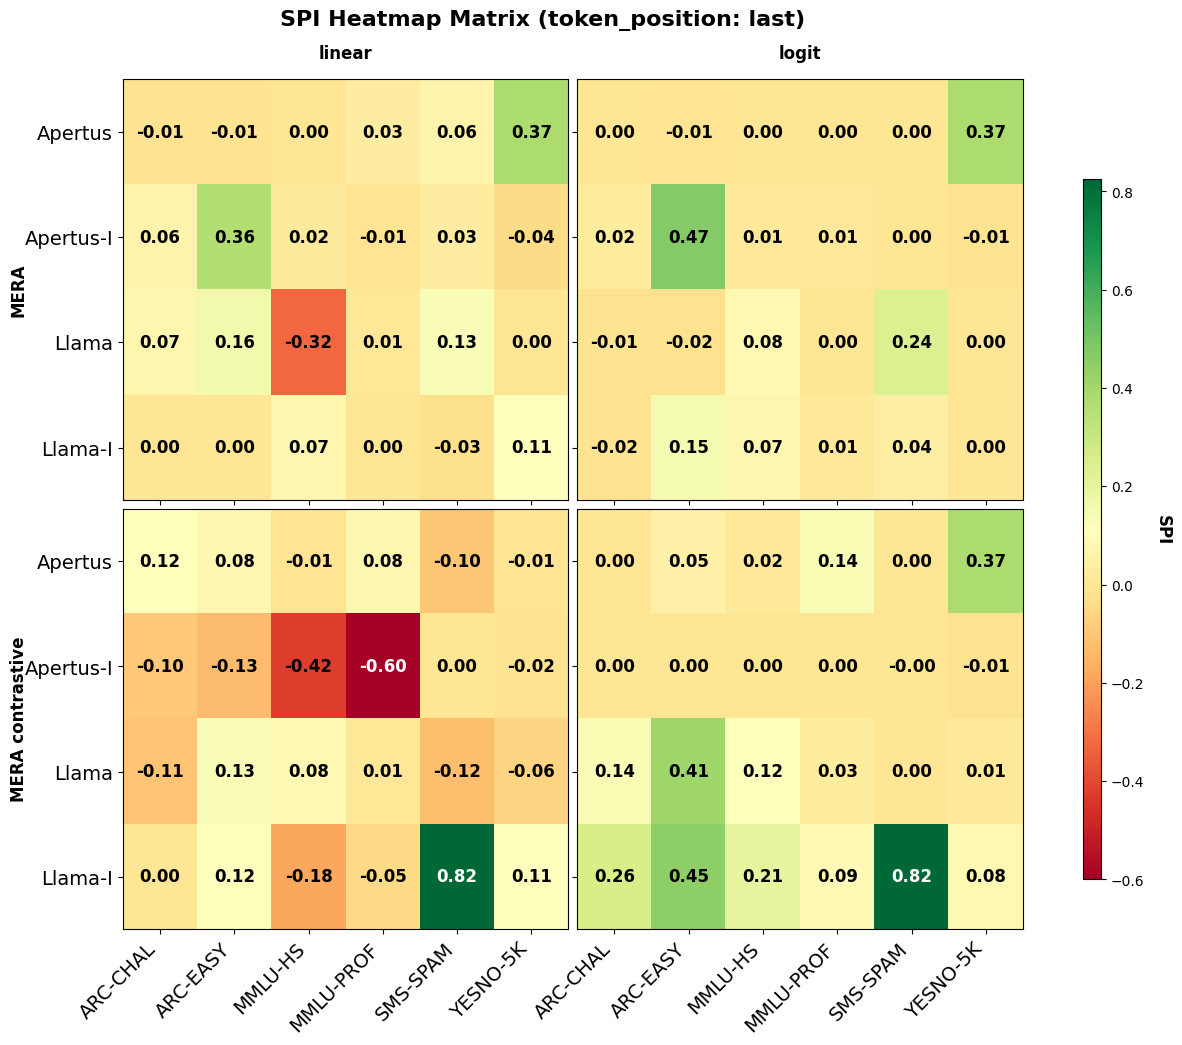

Heatmap matrix saved to: new/heatmap_exact.png


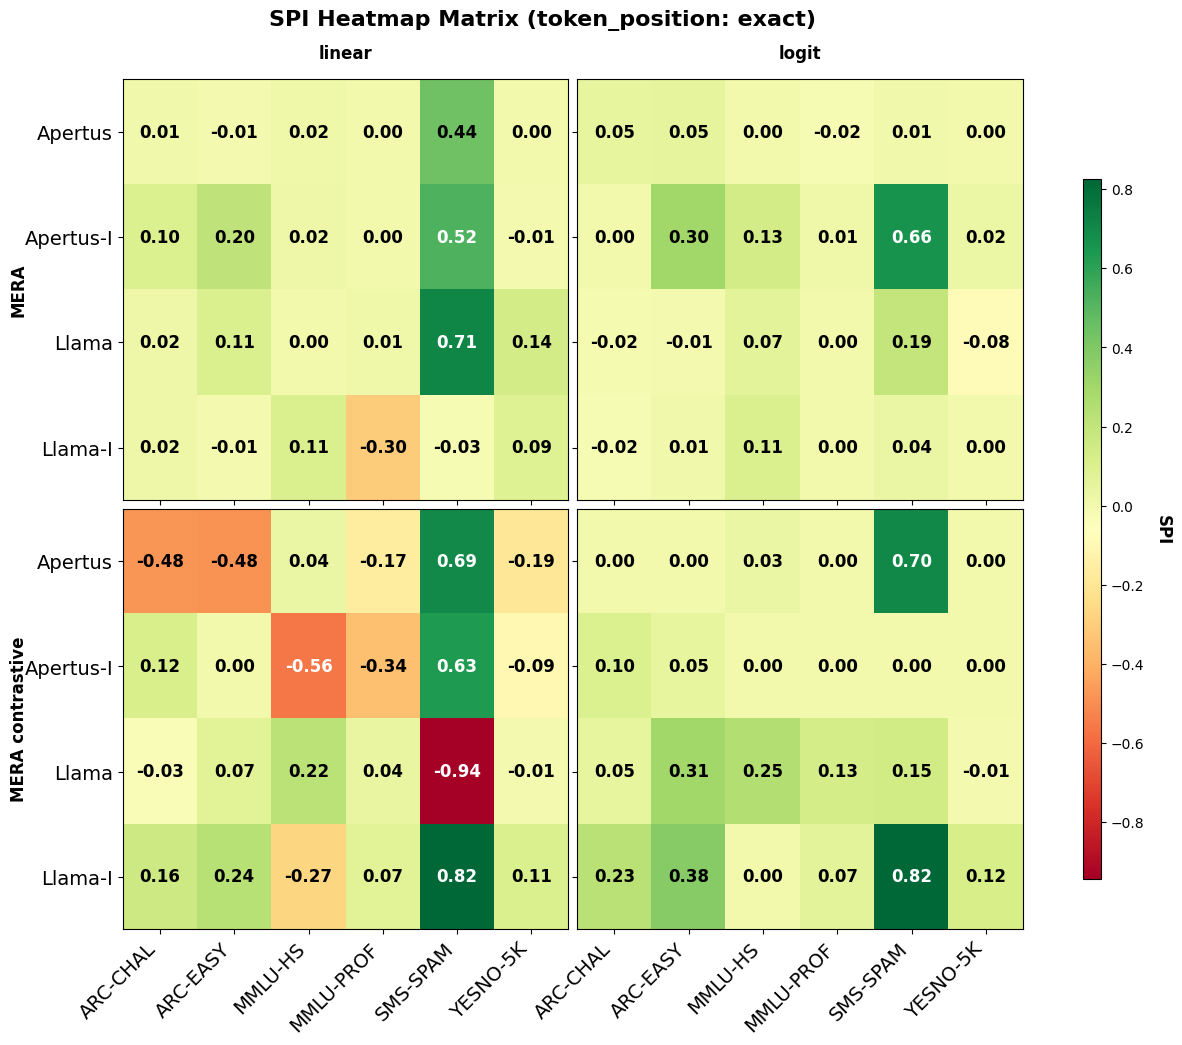

In [59]:
el = plot_spi_heatmap_matrix(
    df=df,
    steering_methods=["MERA", "MERA contrastive"],
    probe_types=["linear", "logit"],
    token_position="last",
    save_path="new/heatmap_last.png"

)

el = plot_spi_heatmap_matrix(
    df=df,
    steering_methods=["MERA", "MERA contrastive"],
    probe_types=["linear", "logit"],
    token_position="exact",
    save_path="new/heatmap_exact.png"
)

In [41]:
# Only compare specific datasets
custom_models = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
    "Apertus-8B-Instruct": "Apertus-8B-Instruct-2509",
    "Llama-3.1-8B": "Llama-3.1-8B",
    "Apertus-8B": "Apertus-8B-2509",
}
df_diff = get_spi_difference_same_vs_mixture(
    models=custom_models,
    probe_types=["logit"],
    same_datasets={
        "MMLU-HS": "mmlu_high_school_steered_on_mmlu_high_school",
        "MMLU-PROF": "mmlu_professional_steered_on_mmlu_professional",
        "ARC-EASY": "ARC-Easy_steered_on_ARC-Easy",
        "ARC-CHAL": "ARC-Challenge_steered_on_ARC-Challenge",
        "SMS-SPAM": "sms_spam_steered_on_sms_spam",
        "YESNO-5K": "sujet_finance_yesno_5k_steered_on_sujet_finance_yesno_5k"
    },
    mixture_datasets = {
        "Mix→MMLU-HS": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_mmlu_high_school",
        "Mix→MMLU-PROF": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_mmlu_professional",
        "Mix→ARC-EASY": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_ARC-Easy",
        "Mix→ARC-CHAL": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_ARC-Challenge",
        "Mix→SMS-SPAM": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_sms_spam",
        "Mix→YESNO-5K": "mmlu_high_school+mmlu_professional+ARC-Challenge+ARC-Easy+sms_spam+sujet_finance_yesno_5k_steered_on_sujet_finance_yesno_5k",
    },

    token_positions=["exact", "last"], 
    debug=True
)
df_diff

Calculating SPI differences: Same-dataset vs Mixture training

[Step 1] Collecting SPI data for same-dataset training...

Processing probe type: logit

Processing token position: exact
Using steering type: logit
Token position: exact
Calibration target: both

[DEBUG] Available steering_keys for MMLU-HS / Llama-3.1-8B-Instruct:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_

,Model,Dataset,Probe Type,Token Position,Method,SPI Same,SPI Mixture,SPI Difference
0,Llama-3.1-8B-Instruct,MMLU-HS,logit,exact,Baseline (prompting),-0.258065,-0.258065,0.000000
1,Llama-3.1-8B-Instruct,MMLU-HS,logit,exact,MERA,0.108280,-0.129032,-0.237313
2,Llama-3.1-8B-Instruct,MMLU-HS,logit,exact,MERA logistic,-0.053763,0.000000,0.053763
3,Llama-3.1-8B-Instruct,MMLU-HS,logit,exact,MERA contrastive,0.000000,0.000000,0.000000
4,Llama-3.1-8B-Instruct,MMLU-HS,logit,exact,Baseline Error (Additive),0.108280,-1.000000,-1.108280
...,...,...,...,...,...,...,...,...
229,Apertus-8B,YESNO-5K,logit,last,Baseline (prompting),0.158333,0.158333,0.000000
230,Apertus-8B,YESNO-5K,logit,last,MERA,0.375000,0.000000,-0.375000
231,Apertus-8B,YESNO-5K,logit,last,MERA logistic,0.375000,0.033333,-0.341667
232,Apertus-8B,YESNO-5K,logit,last,MERA contrastive,0.375000,0.375000,0.000000


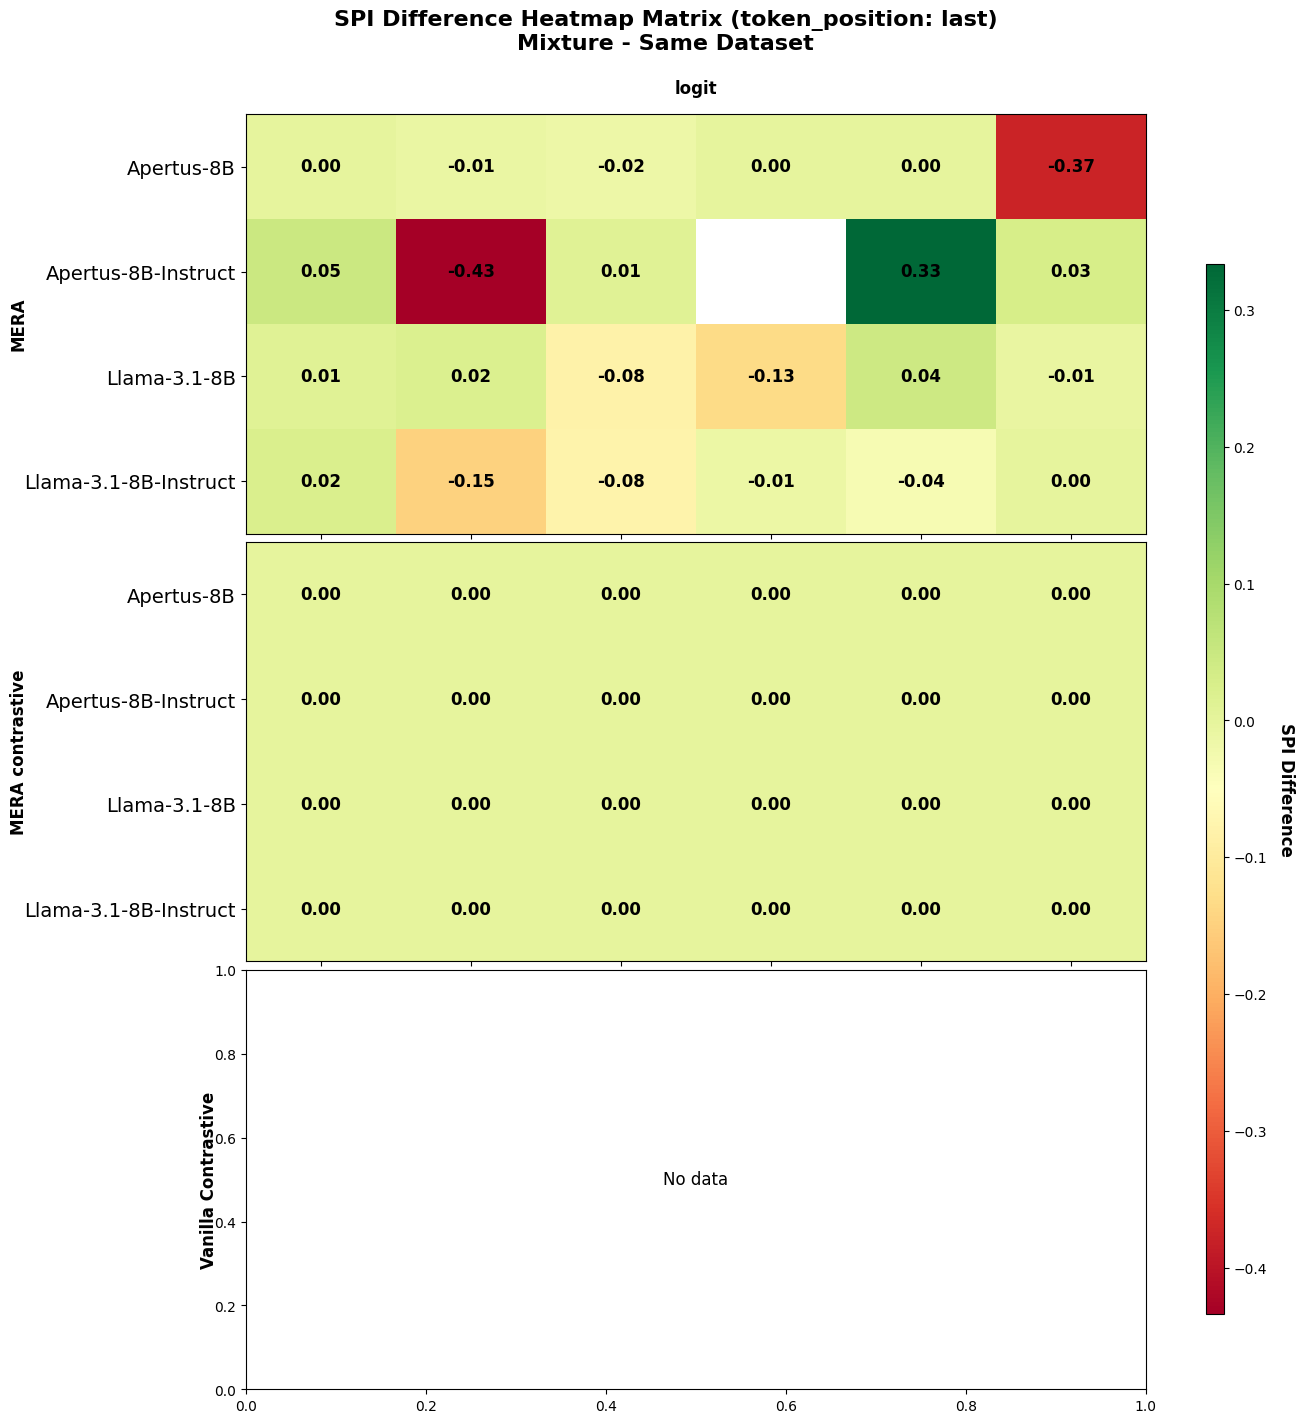

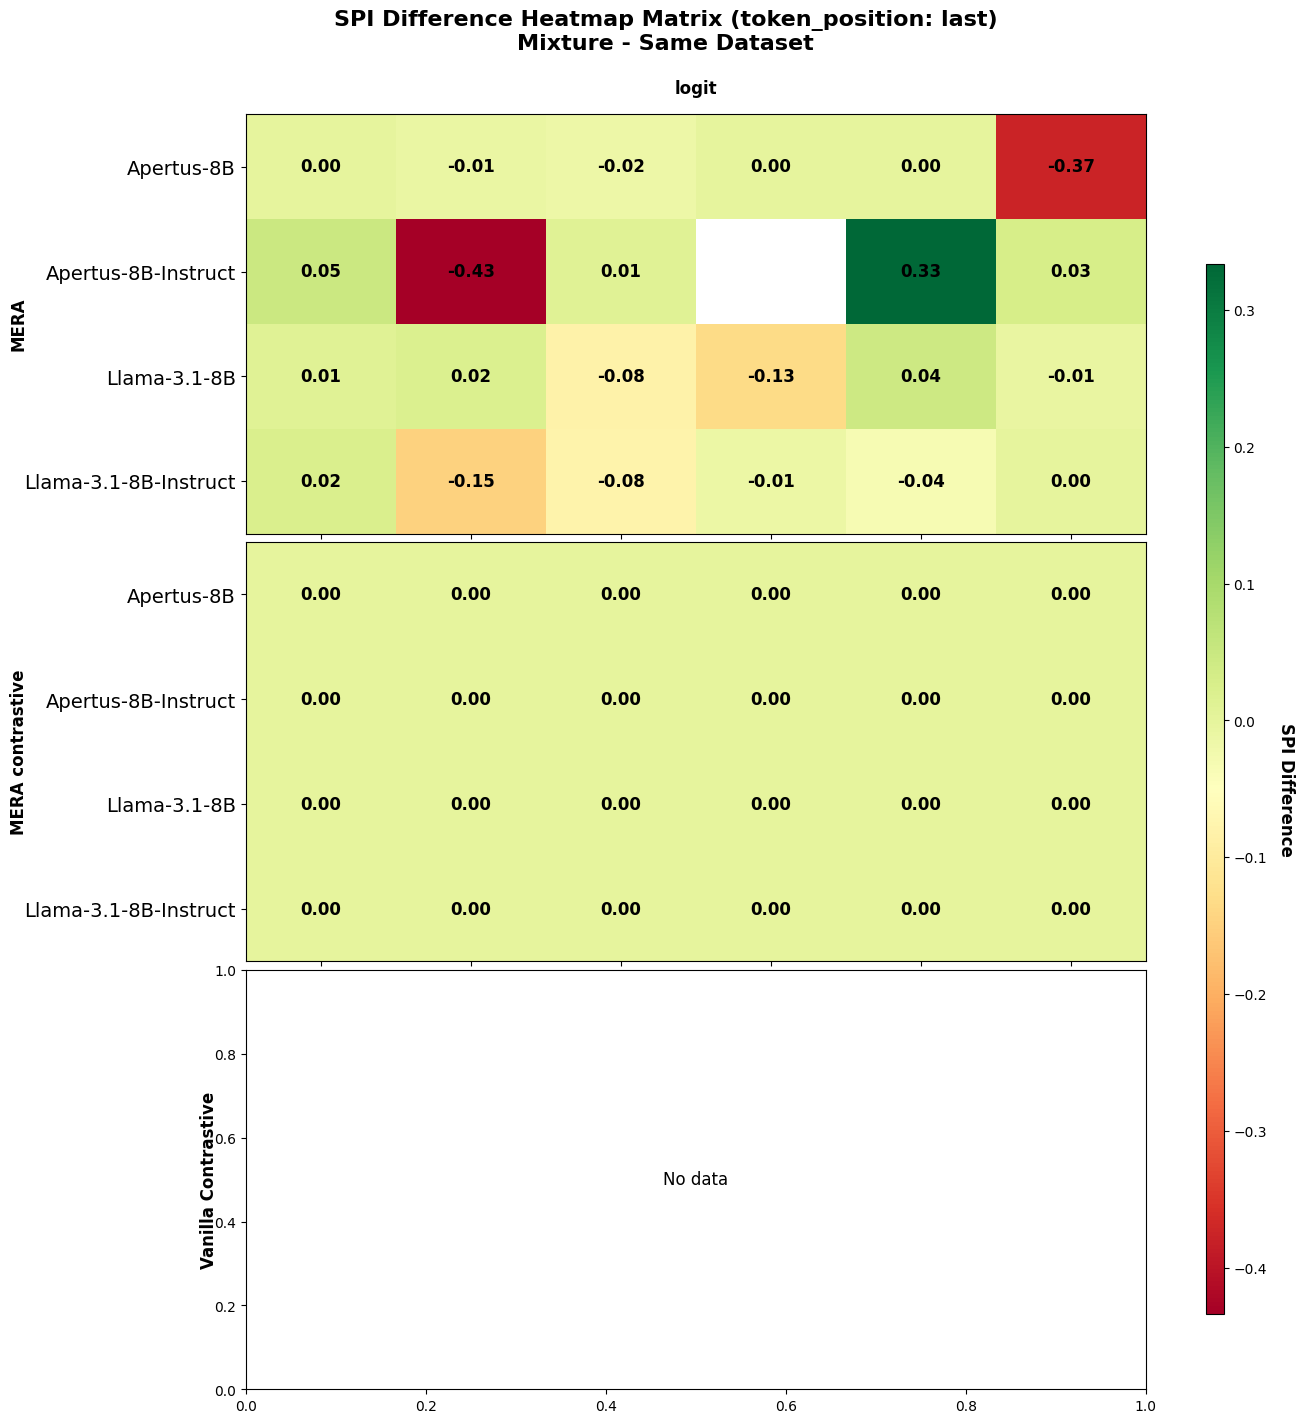

In [ ]:
plot_spi_heatmap_matrix(
    df=df_diff,  # from get_spi_difference_same_vs_mixture()
    steering_methods=["MERA", "MERA contrastive"],
    probe_types=["logit"],
    token_position="last"
)